IMPORTACIÓN DE LIBRERÍAS + CARGA DE DATOS




In [9]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score

from scipy.cluster.hierarchy import dendrogram, linkage

# ## 1. Carga del dataset


df = pd.read_csv("../data/raw/internal-link(7).csv")
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


SELECCIÓN DE VARIABLES + ESCALADO

In [10]:
# ## 2. Selección de variables
# Me centro en variables que describen características socioeconómicas y de vivienda.

features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']
df_selected = df[features].copy()
df_selected.describe()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333


In [11]:
# ## 3. Escalado de los datos

# %%
scaler = StandardScaler()
X = scaler.fit_transform(df_selected)
X[:5]

array([[ 2.34476576,  0.98214266,  0.62855945, -0.15375759, -0.9744286 ,
        -0.04959654],
       [ 2.33223796, -0.60701891,  0.32704136, -0.26333577,  0.86143887,
        -0.09251223],
       [ 1.7826994 ,  1.85618152,  1.15562047, -0.04901636, -0.82077735,
        -0.02584253],
       [ 0.93296751,  1.85618152,  0.15696608, -0.04983292, -0.76602806,
        -0.0503293 ],
       [-0.012881  ,  1.85618152,  0.3447108 , -0.03290586, -0.75984669,
        -0.08561576]])

 KMEANS — MÉTODO DEL CODO

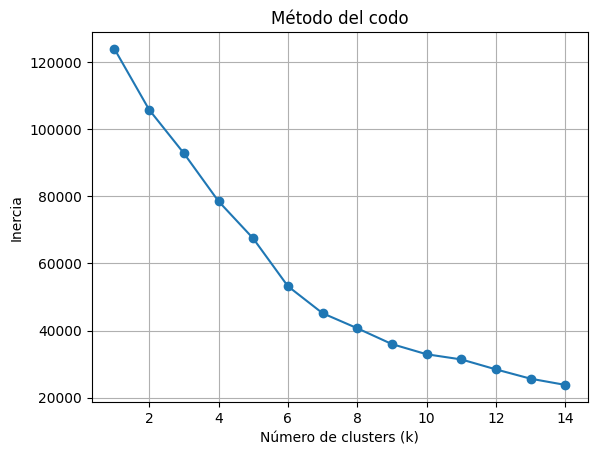

In [12]:

# ## 4. Método del codo (Elbow Method)
# Pruebo distintos valores de k para ver dónde se forma un “codo”.

# %%
inertia = []
K = range(1, 15)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(K, inertia, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del codo')
plt.grid(True)
plt.show()


SILHOUETTE SCORE + DAVIES–BOULDIN

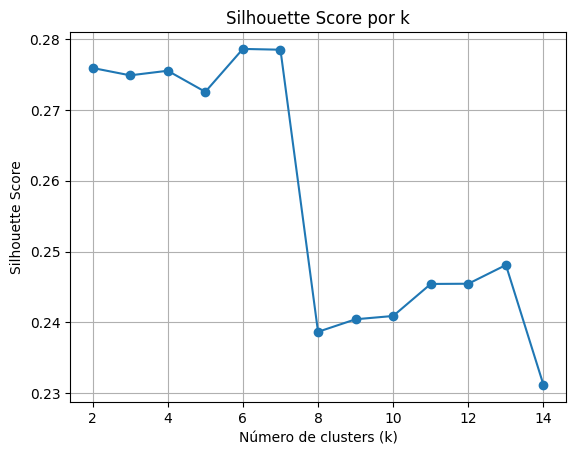

In [13]:
# ## 5. Silhouette Score
# Me ayuda a ver qué tan bien se separan los clusters.


silhouette_scores = []
K_sil = range(2, 15)

for k in K_sil:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X)
    silhouette_scores.append(silhouette_score(X, labels))

plt.figure()
plt.plot(K_sil, silhouette_scores, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score por k')
plt.grid(True)
plt.show()


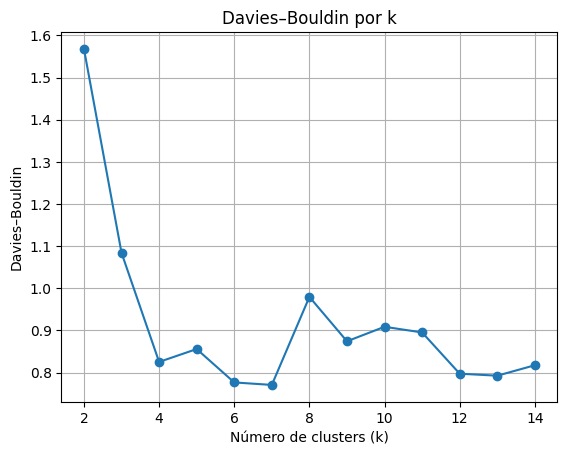

In [14]:
# ## 6. Davies–Bouldin Score
# Valores más bajos indican clusters más definidos.

# 
db_scores = []
K_db = range(2, 15)

for k in K_db:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X)
    db_scores.append(davies_bouldin_score(X, labels))

plt.figure()
plt.plot(K_db, db_scores, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Davies–Bouldin')
plt.title('Davies–Bouldin por k')
plt.grid(True)
plt.show()

DENDOGRAMA + DBSCAN

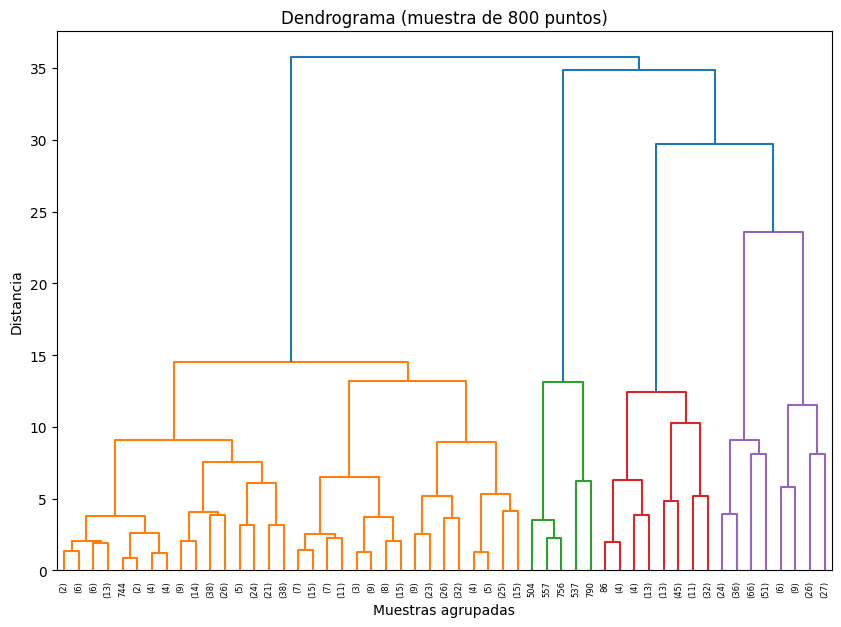

In [15]:
# 7. Dendrograma (Clustering jerárquico)
# Para evitar que el cálculo sea demasiado pesado y bloquee el kernel,
# uso solo una muestra de los datos.


from sklearn.utils import resample

# Tomo una muestra de 800 puntos para el dendrograma
X_sample = resample(X, n_samples=800, random_state=42)

linked = linkage(X_sample, method='ward')

plt.figure(figsize=(10, 7))
dendrogram(linked, truncate_mode='level', p=5)
plt.title('Dendrograma (muestra de 800 puntos)')
plt.xlabel('Muestras agrupadas')
plt.ylabel('Distancia')
plt.show()

Clusters encontrados (incluyendo ruido -1): {np.int64(0), np.int64(-1)}


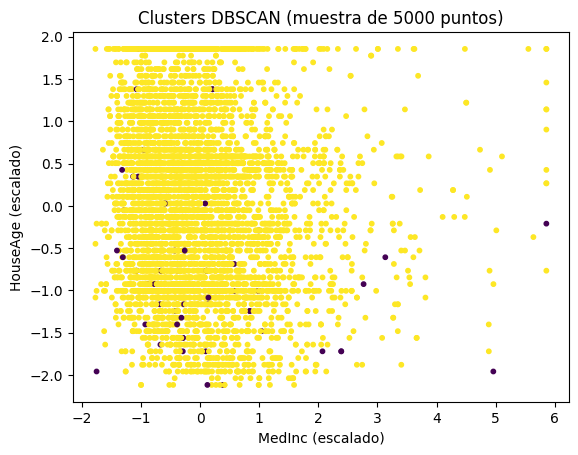

In [16]:
# ## 8. DBSCAN
# Para que DBSCAN no sea demasiado pesado, también uso una muestra de los datos.

# %%
from sklearn.utils import resample

# Muestra de 5000 puntos para DBSCAN
X_db = resample(X, n_samples=5000, random_state=42)

db = DBSCAN(eps=1.5, min_samples=10)
labels_db = db.fit_predict(X_db)

print("Clusters encontrados (incluyendo ruido -1):", set(labels_db))

# %% [markdown]
# ### Visualización de DBSCAN (con dos variables)

# %%
plt.figure()
plt.scatter(X_db[:, 0], X_db[:, 1], c=labels_db, s=10)
plt.xlabel('MedInc (escalado)')
plt.ylabel('HouseAge (escalado)')
plt.title('Clusters DBSCAN (muestra de 5000 puntos)')
plt.show()

INFORME FINAL
Informe de Conclusiones del Proyecto de Clustering

En este proyecto he trabajado con un dataset que contiene información socioeconómica relacionada con viviendas. Mi objetivo ha sido identificar grupos o patrones que puedan existir dentro de los datos, utilizando diferentes técnicas de clustering.

Primero realicé una selección de variables centradas en ingresos, antigüedad de las viviendas, número de habitaciones, dormitorios, población y ocupación media. Estas características me parecieron relevantes para entender cómo se diferencian unas zonas de otras. Como cada variable tenía escalas diferentes, fue necesario estandarizarlas para que todas aportaran de forma equilibrada al modelo.

Después apliqué el método del codo con KMeans. En la gráfica pude observar cómo la inercia iba disminuyendo conforme aumentaba el número de clusters, pero a partir de cierto punto la mejora era pequeña. Esto me ayudó a hacerme una idea del rango adecuado para elegir k.

Complementé este análisis con los indicadores Silhouette Score y Davies–Bouldin. El Silhouette me permitió ver qué valores de k daban una separación más clara entre grupos, mientras que Davies–Bouldin me mostró qué clusters eran más compactos y distinguibles entre sí. Comparando todas las métricas pude identificar el valor de k que tenía más sentido para los datos.

También utilicé un dendrograma para ver cómo se agrupan los datos de manera jerárquica. Esta visualización me ayudó a entender las distancias entre los grupos y las posibles divisiones naturales en el dataset.

Por último, probé con DBSCAN, que es un método diferente porque no necesita elegir k y detecta puntos de ruido. Este algoritmo me permitió ver posibles valores atípicos y clusters con formas menos regulares.

En general, el análisis me permitió comprender que los datos sí presentan patrones claros y que hay grupos diferenciados según las características socioeconómicas. Los métodos utilizados me dieron distintas perspectivas del mismo problema y pude confirmar que el clustering es útil para segmentar este tipo de información. Gracias a esto, tengo una visión más completa de cómo se puede explorar un dataset mediante técnicas no supervisadas.
